In [27]:
feature_names = [
                "ISOTOPE",
                "atomic num >103",
                "Group IVa,Va,VIa Rows 4-6 ",
                "actinide",
                "Group IIIB,IVB",
                "Lanthanide",
                "Group VB,VIB,VIIB",
                "QAAA@1",
                "Group VIII (Fe...)",
                "Group IIa (Alkaline earth)",
                "4M Ring",
                "Group IB,IIB (Cu..)",
                "ON(C)C",
                "S-S",
                "OC(O)O",
                "QAA@1",
                "CTC",
                "Group IIIA (B...) ",
                "7M Ring",
                "Si",
                "C=C(Q)Q",
                "3M Ring",
                "NC(O)O",
                "N-O",
                "NC(N)N",
                "C$=C($A)$A",
                "I",
                "QCH2Q",
                "P",
                "CQ(C)(C)A",
                "QX",
                "CSN",
                "NS",
                "CH2=A",
                "Group IA (Alkali Metal)",
                "S Heterocycle",
                "NC(O)N",
                "NC(C)N",
                "OS(O)O",
                "S-O",
                "CTN",
                "F",
                "QHAQH",
                "OTHER",
                "C=CN",
                "BR",
                "SAN",
                "OQ(O)O",
                "CHARGE  ",
                "C=C(C)C",
                "CSO",
                "NN",
                "QHAAAQH",
                "QHAAQH",
                "OSO",
                "ON(O)C",
                "O Heterocycle",
                "QSQ",
                "Snot%A%A",
                "S=O",
                "AS(A)A",
                "A$!A$A",
                "N=O",
                "A$A!S",
                "C%N",
                "CC(C)(C)A",
                "QS",
                "QHQH",
                "QQH",
                "QNQ",
                "NO",
                "OAAO",
                "S=A",
                "CH3ACH3",
                "A!N$A",
                "C=C(A)A",
                "NAN",
                "C=N",
                "NAAN",
                "NAAAN",
                "SA(A)A",
                "ACH2QH",
                "QAAAA@1",
                "NH2",
                "CN(C)C",
                "CH2QCH2",
                "X!A$A",
                "S",
                "OAAAO",
                "QHAACH2A",
                "QHAAACH2A",
                "OC(N)C",
                "QCH3",
                "QN",
                "NAAO",
                "5 M ring",
                "NAAAO",
                "QAAAAA@1",
                "C=C",
                "ACH2N",
                "8M Ring or larger",
                "QO",
                "CL",
                "QHACH2A",
                "A$A($A)$A",
                "QA(Q)Q",
                "XA(A)A",
                "CH3AAACH2A",
                "ACH2O",
                "NCO",
                "NACH2A",
                "AA(A)(A)A",
                "Onot%A%A",
                "CH3CH2A",
                "CH3ACH2A",
                "CH3AACH2A",
                "NAO",
                "ACH2CH2A > 1",
                "N=A",
                "Heterocyclic atom > 1",
                "N Heterocycle",
                "AN(A)A",
                "OCO",
                "QQ",
                "Aromatic Ring > 1",
                "A!O!A",
                "A$A!O > 1",
                "ACH2AAACH2A",
                "ACH2AACH2A",
                "QQ > 1",
                "QH > 1",
                "OACH2A",
                "A$A!N",
                "X (HALOGEN)",
                "Nnot%A%A",
                "O=A>1 ",
                "Heterocycle",
                "QCH2A>1",
                "OH",
                "O > 3",
                "CH3 > 2",
                "N > 1",
                "A$A!O",
                "Anot%A%Anot%A",
                "6M ring > 1",
                "O > 2",
                "ACH2CH2A",
                "AQ(A)A",
                "CH3 > 1",
                "A!A$A!A",
                "NH",
                "OC(C)C",
                "QCH2A",
                "C=O",
                "A!CH2!A",
                "NA(A)A",
                "C-O",
                "C-N",
                "O>1",
                "CH3",
                "N",
                "Aromatic",
                "6M Ring",
                "O",
                "Ring",
                "Fragments",
            ]
column_mapping = {f"maccsfingerprint{i}": feature_names[i] for i in range(len(feature_names))}

In [2]:
smartsPatts = {
  1: ('?', 0),  # ISOTOPE
  #2:('[#104,#105,#106,#107,#106,#109,#110,#111,#112]',0),  # atomic num >103 Not complete
  2: ('[#104]', 0),  # limit the above def'n since the RDKit only accepts up to #104
  3: ('[#32,#33,#34,#50,#51,#52,#82,#83,#84]', 0),  # Group IVa,Va,VIa Rows 4-6
  4: ('[Ac,Th,Pa,U,Np,Pu,Am,Cm,Bk,Cf,Es,Fm,Md,No,Lr]', 0),  # actinide
  5: ('[Sc,Ti,Y,Zr,Hf]', 0),  # Group IIIB,IVB (Sc...)
  6: ('[La,Ce,Pr,Nd,Pm,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu]', 0),  # Lanthanide
  7: ('[V,Cr,Mn,Nb,Mo,Tc,Ta,W,Re]', 0),  # Group VB,VIB,VIIB
  8: ('[!#6;!#1]1~*~*~*~1', 0),  # QAAA@1
  9: ('[Fe,Co,Ni,Ru,Rh,Pd,Os,Ir,Pt]', 0),  # Group VIII (Fe...)
  10: ('[Be,Mg,Ca,Sr,Ba,Ra]', 0),  # Group IIa (Alkaline earth)
  11: ('*1~*~*~*~1', 0),  # 4M Ring
  12: ('[Cu,Zn,Ag,Cd,Au,Hg]', 0),  # Group IB,IIB (Cu..)
  13: ('[#8]~[#7](~[#6])~[#6]', 0),  # ON(C)C
  14: ('[#16]-[#16]', 0),  # S-S
  15: ('[#8]~[#6](~[#8])~[#8]', 0),  # OC(O)O
  16: ('[!#6;!#1]1~*~*~1', 0),  # QAA@1
  17: ('[#6]#[#6]', 0),  #CTC
  18: ('[#5,#13,#31,#49,#81]', 0),  # Group IIIA (B...)
  19: ('*1~*~*~*~*~*~*~1', 0),  # 7M Ring
  20: ('[#14]', 0),  #Si
  21: ('[#6]=[#6](~[!#6;!#1])~[!#6;!#1]', 0),  # C=C(Q)Q
  22: ('*1~*~*~1', 0),  # 3M Ring
  23: ('[#7]~[#6](~[#8])~[#8]', 0),  # NC(O)O
  24: ('[#7]-[#8]', 0),  # N-O
  25: ('[#7]~[#6](~[#7])~[#7]', 0),  # NC(N)N
  26: ('[#6]=;@[#6](@*)@*', 0),  # C$=C($A)$A
  27: ('[I]', 0),  # I
  28: ('[!#6;!#1]~[CH2]~[!#6;!#1]', 0),  # QCH2Q
  29: ('[#15]', 0),  # P
  30: ('[#6]~[!#6;!#1](~[#6])(~[#6])~*', 0),  # CQ(C)(C)A
  31: ('[!#6;!#1]~[F,Cl,Br,I]', 0),  # QX
  32: ('[#6]~[#16]~[#7]', 0),  # CSN
  33: ('[#7]~[#16]', 0),  # NS
  34: ('[CH2]=*', 0),  # CH2=A
  35: ('[Li,Na,K,Rb,Cs,Fr]', 0),  # Group IA (Alkali Metal)
  36: ('[#16R]', 0),  # S Heterocycle
  37: ('[#7]~[#6](~[#8])~[#7]', 0),  # NC(O)N
  38: ('[#7]~[#6](~[#6])~[#7]', 0),  # NC(C)N
  39: ('[#8]~[#16](~[#8])~[#8]', 0),  # OS(O)O
  40: ('[#16]-[#8]', 0),  # S-O
  41: ('[#6]#[#7]', 0),  # CTN
  42: ('F', 0),  # F
  43: ('[!#6;!#1;!H0]~*~[!#6;!#1;!H0]', 0),  # QHAQH
  44: ('[!#1;!#6;!#7;!#8;!#9;!#14;!#15;!#16;!#17;!#35;!#53]', 0),  # OTHER
  45: ('[#6]=[#6]~[#7]', 0),  # C=CN
  46: ('Br', 0),  # BR
  47: ('[#16]~*~[#7]', 0),  # SAN
  48: ('[#8]~[!#6;!#1](~[#8])(~[#8])', 0),  # OQ(O)O
  49: ('[!+0]', 0),  # CHARGE
  50: ('[#6]=[#6](~[#6])~[#6]', 0),  # C=C(C)C
  51: ('[#6]~[#16]~[#8]', 0),  # CSO
  52: ('[#7]~[#7]', 0),  # NN
  53: ('[!#6;!#1;!H0]~*~*~*~[!#6;!#1;!H0]', 0),  # QHAAAQH
  54: ('[!#6;!#1;!H0]~*~*~[!#6;!#1;!H0]', 0),  # QHAAQH
  55: ('[#8]~[#16]~[#8]', 0),  #OSO
  56: ('[#8]~[#7](~[#8])~[#6]', 0),  # ON(O)C
  57: ('[#8R]', 0),  # O Heterocycle
  58: ('[!#6;!#1]~[#16]~[!#6;!#1]', 0),  # QSQ
  59: ('[#16]!:*:*', 0),  # Snot%A%A
  60: ('[#16]=[#8]', 0),  # S=O
  61: ('*~[#16](~*)~*', 0),  # AS(A)A
  62: ('*@*!@*@*', 0),  # A$!A$A
  63: ('[#7]=[#8]', 0),  # N=O
  64: ('*@*!@[#16]', 0),  # A$A!S
  65: ('c:n', 0),  # C%N
  66: ('[#6]~[#6](~[#6])(~[#6])~*', 0),  # CC(C)(C)A
  67: ('[!#6;!#1]~[#16]', 0),  # QS
  68: ('[!#6;!#1;!H0]~[!#6;!#1;!H0]', 0),  # QHQH (&...) SPEC Incomplete
  69: ('[!#6;!#1]~[!#6;!#1;!H0]', 0),  # QQH
  70: ('[!#6;!#1]~[#7]~[!#6;!#1]', 0),  # QNQ
  71: ('[#7]~[#8]', 0),  # NO
  72: ('[#8]~*~*~[#8]', 0),  # OAAO
  73: ('[#16]=*', 0),  # S=A
  74: ('[CH3]~*~[CH3]', 0),  # CH3ACH3
  75: ('*!@[#7]@*', 0),  # A!N$A
  76: ('[#6]=[#6](~*)~*', 0),  # C=C(A)A
  77: ('[#7]~*~[#7]', 0),  # NAN
  78: ('[#6]=[#7]', 0),  # C=N
  79: ('[#7]~*~*~[#7]', 0),  # NAAN
  80: ('[#7]~*~*~*~[#7]', 0),  # NAAAN
  81: ('[#16]~*(~*)~*', 0),  # SA(A)A
  82: ('*~[CH2]~[!#6;!#1;!H0]', 0),  # ACH2QH
  83: ('[!#6;!#1]1~*~*~*~*~1', 0),  # QAAAA@1
  84: ('[NH2]', 0),  #NH2
  85: ('[#6]~[#7](~[#6])~[#6]', 0),  # CN(C)C
  86: ('[C;H2,H3][!#6;!#1][C;H2,H3]', 0),  # CH2QCH2
  87: ('[F,Cl,Br,I]!@*@*', 0),  # X!A$A
  88: ('[#16]', 0),  # S
  89: ('[#8]~*~*~*~[#8]', 0),  # OAAAO
  90:
  ('[$([!#6;!#1;!H0]~*~*~[CH2]~*),$([!#6;!#1;!H0;R]1@[R]@[R]@[CH2;R]1),$([!#6;!#1;!H0]~[R]1@[R]@[CH2;R]1)]',
   0),  # QHAACH2A
  91:
  ('[$([!#6;!#1;!H0]~*~*~*~[CH2]~*),$([!#6;!#1;!H0;R]1@[R]@[R]@[R]@[CH2;R]1),$([!#6;!#1;!H0]~[R]1@[R]@[R]@[CH2;R]1),$([!#6;!#1;!H0]~*~[R]1@[R]@[CH2;R]1)]',
   0),  # QHAAACH2A
  92: ('[#8]~[#6](~[#7])~[#6]', 0),  # OC(N)C
  93: ('[!#6;!#1]~[CH3]', 0),  # QCH3
  94: ('[!#6;!#1]~[#7]', 0),  # QN
  95: ('[#7]~*~*~[#8]', 0),  # NAAO
  96: ('*1~*~*~*~*~1', 0),  # 5 M ring
  97: ('[#7]~*~*~*~[#8]', 0),  # NAAAO
  98: ('[!#6;!#1]1~*~*~*~*~*~1', 0),  # QAAAAA@1
  99: ('[#6]=[#6]', 0),  # C=C
  100: ('*~[CH2]~[#7]', 0),  # ACH2N
  101:
  ('[$([R]@1@[R]@[R]@[R]@[R]@[R]@[R]@[R]1),$([R]@1@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]1),$([R]@1@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]1),$([R]@1@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]1),$([R]@1@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]1),$([R]@1@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]1),$([R]@1@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]1)]',
   0),  # 8M Ring or larger. This only handles up to ring sizes of 14
  102: ('[!#6;!#1]~[#8]', 0),  # QO
  103: ('Cl', 0),  # CL
  104: ('[!#6;!#1;!H0]~*~[CH2]~*', 0),  # QHACH2A
  105: ('*@*(@*)@*', 0),  # A$A($A)$A
  106: ('[!#6;!#1]~*(~[!#6;!#1])~[!#6;!#1]', 0),  # QA(Q)Q
  107: ('[F,Cl,Br,I]~*(~*)~*', 0),  # XA(A)A
  108: ('[CH3]~*~*~*~[CH2]~*', 0),  # CH3AAACH2A
  109: ('*~[CH2]~[#8]', 0),  # ACH2O
  110: ('[#7]~[#6]~[#8]', 0),  # NCO
  111: ('[#7]~*~[CH2]~*', 0),  # NACH2A
  112: ('*~*(~*)(~*)~*', 0),  # AA(A)(A)A
  113: ('[#8]!:*:*', 0),  # Onot%A%A
  114: ('[CH3]~[CH2]~*', 0),  # CH3CH2A
  115: ('[CH3]~*~[CH2]~*', 0),  # CH3ACH2A
  116: ('[$([CH3]~*~*~[CH2]~*),$([CH3]~*1~*~[CH2]1)]', 0),  # CH3AACH2A
  117: ('[#7]~*~[#8]', 0),  # NAO
  118: ('[$(*~[CH2]~[CH2]~*),$(*1~[CH2]~[CH2]1)]', 1),  # ACH2CH2A > 1
  119: ('[#7]=*', 0),  # N=A
  120: ('[!#6;R]', 1),  # Heterocyclic atom > 1 (&...) Spec Incomplete
  121: ('[#7;R]', 0),  # N Heterocycle
  122: ('*~[#7](~*)~*', 0),  # AN(A)A
  123: ('[#8]~[#6]~[#8]', 0),  # OCO
  124: ('[!#6;!#1]~[!#6;!#1]', 0),  # QQ
  125: ('?', 0),  # Aromatic Ring > 1
  126: ('*!@[#8]!@*', 0),  # A!O!A
  127: ('*@*!@[#8]', 1),  # A$A!O > 1 (&...) Spec Incomplete
  128:
  ('[$(*~[CH2]~*~*~*~[CH2]~*),$([R]1@[CH2;R]@[R]@[R]@[R]@[CH2;R]1),$(*~[CH2]~[R]1@[R]@[R]@[CH2;R]1),$(*~[CH2]~*~[R]1@[R]@[CH2;R]1)]',
   0),  # ACH2AAACH2A
  129: ('[$(*~[CH2]~*~*~[CH2]~*),$([R]1@[CH2]@[R]@[R]@[CH2;R]1),$(*~[CH2]~[R]1@[R]@[CH2;R]1)]',
        0),  # ACH2AACH2A
  130: ('[!#6;!#1]~[!#6;!#1]', 1),  # QQ > 1 (&...)  Spec Incomplete
  131: ('[!#6;!#1;!H0]', 1),  # QH > 1
  132: ('[#8]~*~[CH2]~*', 0),  # OACH2A
  133: ('*@*!@[#7]', 0),  # A$A!N
  134: ('[F,Cl,Br,I]', 0),  # X (HALOGEN)
  135: ('[#7]!:*:*', 0),  # Nnot%A%A
  136: ('[#8]=*', 1),  # O=A>1
  137: ('[!C;!c;R]', 0),  # Heterocycle
  138: ('[!#6;!#1]~[CH2]~*', 1),  # QCH2A>1 (&...) Spec Incomplete
  139: ('[O;!H0]', 0),  # OH
  140: ('[#8]', 3),  # O > 3 (&...) Spec Incomplete
  141: ('[CH3]', 2),  # CH3 > 2  (&...) Spec Incomplete
  142: ('[#7]', 1),  # N > 1
  143: ('*@*!@[#8]', 0),  # A$A!O
  144: ('*!:*:*!:*', 0),  # Anot%A%Anot%A
  145: ('*1~*~*~*~*~*~1', 1),  # 6M ring > 1
  146: ('[#8]', 2),  # O > 2
  147: ('[$(*~[CH2]~[CH2]~*),$([R]1@[CH2;R]@[CH2;R]1)]', 0),  # ACH2CH2A
  148: ('*~[!#6;!#1](~*)~*', 0),  # AQ(A)A
  149: ('[C;H3,H4]', 1),  # CH3 > 1
  150: ('*!@*@*!@*', 0),  # A!A$A!A
  151: ('[#7;!H0]', 0),  # NH
  152: ('[#8]~[#6](~[#6])~[#6]', 0),  # OC(C)C
  153: ('[!#6;!#1]~[CH2]~*', 0),  # QCH2A
  154: ('[#6]=[#8]', 0),  # C=O
  155: ('*!@[CH2]!@*', 0),  # A!CH2!A
  156: ('[#7]~*(~*)~*', 0),  # NA(A)A
  157: ('[#6]-[#8]', 0),  # C-O
  158: ('[#6]-[#7]', 0),  # C-N
  159: ('[#8]', 1),  # O>1
  160: ('[C;H3,H4]', 0),  #CH3
  161: ('[#7]', 0),  # N
  162: ('a', 0),  # Aromatic
  163: ('*1~*~*~*~*~*~1', 0),  # 6M Ring
  164: ('[#8]', 0),  # O
  165: ('[R]', 0),  # Ring
  166: ('?', 0),  # Fragments  FIX: this can't be done in SMARTS
}
#all_smarts = {f: k[0] for f,k in zip(feature_names, list(smartsPatts.values()))}

maccs_smarts = {f"maccsfingerprint{i}": smartsPatts[i] for i in smartsPatts.keys()}
import json

# Serialize data into file:
json.dump( maccs_smarts, open( "maccs_smarts_mapping.json", 'w' ) )


In [59]:
print(len(feature_names), len(list(smartsPatts.values())))

166 166


In [60]:
all_smarts

{'ISOTOPE': '?',
 'atomic num >103': '[#104]',
 'Group IVa,Va,VIa Rows 4-6 ': '[#32,#33,#34,#50,#51,#52,#82,#83,#84]',
 'actinide': '[Ac,Th,Pa,U,Np,Pu,Am,Cm,Bk,Cf,Es,Fm,Md,No,Lr]',
 'Group IIIB,IVB': '[Sc,Ti,Y,Zr,Hf]',
 'Lanthanide': '[La,Ce,Pr,Nd,Pm,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu]',
 'Group VB,VIB,VIIB': '[V,Cr,Mn,Nb,Mo,Tc,Ta,W,Re]',
 'QAAA@1': '[!#6;!#1]1~*~*~*~1',
 'Group VIII (Fe...)': '[Fe,Co,Ni,Ru,Rh,Pd,Os,Ir,Pt]',
 'Group IIa (Alkaline earth)': '[Be,Mg,Ca,Sr,Ba,Ra]',
 '4M Ring': '*1~*~*~*~1',
 'Group IB,IIB (Cu..)': '[Cu,Zn,Ag,Cd,Au,Hg]',
 'ON(C)C': '[#8]~[#7](~[#6])~[#6]',
 'S-S': '[#16]-[#16]',
 'OC(O)O': '[#8]~[#6](~[#8])~[#8]',
 'QAA@1': '[!#6;!#1]1~*~*~1',
 'CTC': '[#6]#[#6]',
 'Group IIIA (B...) ': '[#5,#13,#31,#49,#81]',
 '7M Ring': '*1~*~*~*~*~*~*~1',
 'Si': '[#14]',
 'C=C(Q)Q': '[#6]=[#6](~[!#6;!#1])~[!#6;!#1]',
 '3M Ring': '*1~*~*~1',
 'NC(O)O': '[#7]~[#6](~[#8])~[#8]',
 'N-O': '[#7]-[#8]',
 'NC(N)N': '[#7]~[#6](~[#7])~[#7]',
 'C$=C($A)$A': '[#6]=;@[#6](@*)@*',
 'I': '[

In [28]:
estate = [
  ('sLi', '[LiD1]-*'),
  ('ssBe', '[BeD2](-*)-*'),
  ('ssssBe', '[BeD4](-*)(-*)(-*)-*'),
  ('ssBH', '[BD2H](-*)-*'),
  ('sssB', '[BD3](-*)(-*)-*'),
  ('ssssB', '[BD4](-*)(-*)(-*)-*'),
  ('sCH3', '[CD1H3]-*'),
  ('dCH2', '[CD1H2]=*'),
  ('ssCH2', '[CD2H2](-*)-*'),
  ('tCH', '[CD1H]#*'),
  ('dsCH', '[CD2H](=*)-*'),
  ('aaCH', '[C,c;D2H](:*):*'),
  ('sssCH', '[CD3H](-*)(-*)-*'),
  ('ddC', '[CD2H0](=*)=*'),
  ('tsC', '[CD2H0](#*)-*'),
  ('dssC', '[CD3H0](=*)(-*)-*'),
  ('aasC', '[C,c;D3H0](:*)(:*)-*'),
  ('aaaC', '[C,c;D3H0](:*)(:*):*'),
  ('ssssC', '[CD4H0](-*)(-*)(-*)-*'),
  ('sNH3', '[ND1H3]-*'),
  ('sNH2', '[ND1H2]-*'),
  ('ssNH2', '[ND2H2](-*)-*'),
  ('dNH', '[ND1H]=*'),
  ('ssNH', '[ND2H](-*)-*'),
  ('aaNH', '[N,nD2H](:*):*'),
  ('tN', '[ND1H0]#*'),
  ('sssNH', '[ND3H](-*)(-*)-*'),
  ('dsN', '[ND2H0](=*)-*'),
  ('aaN', '[N,nD2H0](:*):*'),
  ('sssN', '[ND3H0](-*)(-*)-*'),
  ('ddsN', '[ND3H0](~[OD1H0])(~[OD1H0])-,:*'),  # mod
  ('aasN', '[N,nD3H0](:*)(:*)-,:*'),  # mod
  ('ssssN', '[ND4H0](-*)(-*)(-*)-*'),
  ('sOH', '[OD1H]-*'),
  ('dO', '[OD1H0]=*'),
  ('ssO', '[OD2H0](-*)-*'),
  ('aaO', '[O,oD2H0](:*):*'),
  ('sF', '[FD1]-*'),
  ('sSiH3', '[SiD1H3]-*'),
  ('ssSiH2', '[SiD2H2](-*)-*'),
  ('sssSiH', '[SiD3H1](-*)(-*)-*'),
  ('ssssSi', '[SiD4H0](-*)(-*)(-*)-*'),
  ('sPH2', '[PD1H2]-*'),
  ('ssPH', '[PD2H1](-*)-*'),
  ('sssP', '[PD3H0](-*)(-*)-*'),
  ('dsssP', '[PD4H0](=*)(-*)(-*)-*'),
  ('sssssP', '[PD5H0](-*)(-*)(-*)(-*)-*'),
  ('sSH', '[SD1H1]-*'),
  ('dS', '[SD1H0]=*'),
  ('ssS', '[SD2H0](-*)-*'),
  ('aaS', '[S,sD2H0](:*):*'),
  ('dssS', '[SD3H0](=*)(-*)-*'),
  ('ddssS', '[SD4H0](~[OD1H0])(~[OD1H0])(-*)-*'),  # mod
  ('sCl', '[ClD1]-*'),
  ('sGeH3', '[GeD1H3](-*)'),
  ('ssGeH2', '[GeD2H2](-*)-*'),
  ('sssGeH', '[GeD3H1](-*)(-*)-*'),
  ('ssssGe', '[GeD4H0](-*)(-*)(-*)-*'),
  ('sAsH2', '[AsD1H2]-*'),
  ('ssAsH', '[AsD2H1](-*)-*'),
  ('sssAs', '[AsD3H0](-*)(-*)-*'),
  ('sssdAs', '[AsD4H0](=*)(-*)(-*)-*'),
  ('sssssAs', '[AsD5H0](-*)(-*)(-*)(-*)-*'),
  ('sSeH', '[SeD1H1]-*'),
  ('dSe', '[SeD1H0]=*'),
  ('ssSe', '[SeD2H0](-*)-*'),
  ('aaSe', '[SeD2H0](:*):*'),
  ('dssSe', '[SeD3H0](=*)(-*)-*'),
  ('ddssSe', '[SeD4H0](=*)(=*)(-*)-*'),
  ('sBr', '[BrD1]-*'),
  ('sSnH3', '[SnD1H3]-*'),
  ('ssSnH2', '[SnD2H2](-*)-*'),
  ('sssSnH', '[SnD3H1](-*)(-*)-*'),
  ('ssssSn', '[SnD4H0](-*)(-*)(-*)-*'),
  ('sI', '[ID1]-*'),
  ('sPbH3', '[PbD1H3]-*'),
  ('ssPbH2', '[PbD2H2](-*)-*'),
  ('sssPbH', '[PbD3H1](-*)(-*)-*'),
  ('ssssPb', '[PbD4H0](-*)(-*)(-*)-*'),
]
estate = dict(estate)
estate

{'sLi': '[LiD1]-*',
 'ssBe': '[BeD2](-*)-*',
 'ssssBe': '[BeD4](-*)(-*)(-*)-*',
 'ssBH': '[BD2H](-*)-*',
 'sssB': '[BD3](-*)(-*)-*',
 'ssssB': '[BD4](-*)(-*)(-*)-*',
 'sCH3': '[CD1H3]-*',
 'dCH2': '[CD1H2]=*',
 'ssCH2': '[CD2H2](-*)-*',
 'tCH': '[CD1H]#*',
 'dsCH': '[CD2H](=*)-*',
 'aaCH': '[C,c;D2H](:*):*',
 'sssCH': '[CD3H](-*)(-*)-*',
 'ddC': '[CD2H0](=*)=*',
 'tsC': '[CD2H0](#*)-*',
 'dssC': '[CD3H0](=*)(-*)-*',
 'aasC': '[C,c;D3H0](:*)(:*)-*',
 'aaaC': '[C,c;D3H0](:*)(:*):*',
 'ssssC': '[CD4H0](-*)(-*)(-*)-*',
 'sNH3': '[ND1H3]-*',
 'sNH2': '[ND1H2]-*',
 'ssNH2': '[ND2H2](-*)-*',
 'dNH': '[ND1H]=*',
 'ssNH': '[ND2H](-*)-*',
 'aaNH': '[N,nD2H](:*):*',
 'tN': '[ND1H0]#*',
 'sssNH': '[ND3H](-*)(-*)-*',
 'dsN': '[ND2H0](=*)-*',
 'aaN': '[N,nD2H0](:*):*',
 'sssN': '[ND3H0](-*)(-*)-*',
 'ddsN': '[ND3H0](~[OD1H0])(~[OD1H0])-,:*',
 'aasN': '[N,nD3H0](:*)(:*)-,:*',
 'ssssN': '[ND4H0](-*)(-*)(-*)-*',
 'sOH': '[OD1H]-*',
 'dO': '[OD1H0]=*',
 'ssO': '[OD2H0](-*)-*',
 'aaO': '[O,oD2H0](:*):*',

In [61]:
all_smarts.update(estate)

In [29]:
estate_features = {f'estatefingerprint{i}': list(estate.keys())[i]  for i in range(len(list(estate.keys())))}
estate_features

{'estatefingerprint0': 'sLi',
 'estatefingerprint1': 'ssBe',
 'estatefingerprint2': 'ssssBe',
 'estatefingerprint3': 'ssBH',
 'estatefingerprint4': 'sssB',
 'estatefingerprint5': 'ssssB',
 'estatefingerprint6': 'sCH3',
 'estatefingerprint7': 'dCH2',
 'estatefingerprint8': 'ssCH2',
 'estatefingerprint9': 'tCH',
 'estatefingerprint10': 'dsCH',
 'estatefingerprint11': 'aaCH',
 'estatefingerprint12': 'sssCH',
 'estatefingerprint13': 'ddC',
 'estatefingerprint14': 'tsC',
 'estatefingerprint15': 'dssC',
 'estatefingerprint16': 'aasC',
 'estatefingerprint17': 'aaaC',
 'estatefingerprint18': 'ssssC',
 'estatefingerprint19': 'sNH3',
 'estatefingerprint20': 'sNH2',
 'estatefingerprint21': 'ssNH2',
 'estatefingerprint22': 'dNH',
 'estatefingerprint23': 'ssNH',
 'estatefingerprint24': 'aaNH',
 'estatefingerprint25': 'tN',
 'estatefingerprint26': 'sssNH',
 'estatefingerprint27': 'dsN',
 'estatefingerprint28': 'aaN',
 'estatefingerprint29': 'sssN',
 'estatefingerprint30': 'ddsN',
 'estatefingerprint

In [30]:
column_mapping.update(estate_features)
len(column_mapping)

245

In [31]:
root_dir = '../../../data'
target = 'capacity_max'

metrics = ["pairwise_accuracy_score", "ndcg_score", "rmse", "mape"]
models = ["random_forest", "xgboost"]

data_dict = {
  'expert': 'data_experts1.csv',
  'zhu': 'data_zhu.csv',
  'saad': 'data_saad.csv',
  'expert2': 'data_experts2.csv',
  'expert3': 'data_experts3.csv',
}

features = ['fingerprints_maccs', 'fingerprints_estate']

combo = ['expert', 'zhu', 'saad', 'expert2', 'expert3']

In [32]:
import shap
import numpy as np

# def visualize_shap(shap_values_list, df_features, columns_mapping=None):
#     test_set, shap_set = np.array(shap_values_list[0][1]), np.array(shap_values_list[0][0])
#     for i in range(0,len(shap_values_list)):
#         i_test_set, i_shap_set = np.array(shap_values_list[i][1]), shap_values_list[i][0]
#         display(shap.plots.beeswarm(i_shap_set))

def visualize_shap(shap_values_list, df_features, columns_mapping=None):
    test_ids = []
    shap_values_per_fold = []
    for i in range(len(shap_values_list)):
        shaps = shap_values_list[i][0]
        shap_values_per_fold.extend(shaps)
        test_ids.extend(shap_values_list[i][1])

    display(shap.summary_plot(np.array(shap_values_per_fold),
                      df_features.loc[test_ids, :],
                      max_display=10,
                      feature_names=list(columns_mapping.values()),
                      show=True))

In [33]:
import pandas as pd
import os

dataset_paths = {data_name: [os.path.join(root_dir, data_type, data_dict[data_name]) for data_type in features] for data_name in combo}
dfs = {}
for data_name, data_paths in dataset_paths.items():
        df_read = [pd.read_csv(data_path) for data_path in data_paths]
        df = df_read[0]
        for data in df_read[1:]:
            data = data.drop(columns=['capacity_max'])
            df = pd.merge(df, data, on='smiles', how='inner')
        df.columns = df.columns.str.replace(r"[\[\]>]", "", regex=True)
        df = df.sort_values(by="smiles").reset_index(drop=True)
        dfs[data_name] = df

# df_expert1 = dfs["expert"]
# df_expert2 = dfs["expert2"]

In [34]:
from modules.predictor.data.utils import custom_data_kfold, combine_split

num_splits = 10
num_bins = 5
random_state = 42

df_all = pd.concat([df for data_name, df in dfs.items()], ignore_index=True).sort_values(by="smiles").reset_index(drop=True)
df_all.fillna(0, inplace=True)
df_rest = None
print(df_all[df_all.isnull().any(axis=1)])

folds_all = custom_data_kfold(df_all, df_all.loc[:, [target]], num_splits, num_bins, random_state)


Empty DataFrame
Columns: [maccsfingerprint0, maccsfingerprint1, maccsfingerprint2, maccsfingerprint3, maccsfingerprint4, maccsfingerprint5, maccsfingerprint6, maccsfingerprint7, maccsfingerprint8, maccsfingerprint9, maccsfingerprint10, maccsfingerprint11, maccsfingerprint12, maccsfingerprint13, maccsfingerprint14, maccsfingerprint15, maccsfingerprint16, maccsfingerprint17, maccsfingerprint18, maccsfingerprint19, maccsfingerprint20, maccsfingerprint21, maccsfingerprint22, maccsfingerprint23, maccsfingerprint24, maccsfingerprint25, maccsfingerprint26, maccsfingerprint27, maccsfingerprint28, maccsfingerprint29, maccsfingerprint30, maccsfingerprint31, maccsfingerprint32, maccsfingerprint33, maccsfingerprint34, maccsfingerprint35, maccsfingerprint36, maccsfingerprint37, maccsfingerprint38, maccsfingerprint39, maccsfingerprint40, maccsfingerprint41, maccsfingerprint42, maccsfingerprint43, maccsfingerprint44, maccsfingerprint45, maccsfingerprint46, maccsfingerprint47, maccsfingerprint48, macc

In [35]:
X_all = df_all.drop(columns=[target, "smiles"])
y_all = df_all.loc[:, [target]]
num_features = [f for f in X_all.columns if 'estate' in f]
bin_features = []#[f for f in X_all.columns if 'maccs' in f]

In [36]:
X_all

,maccsfingerprint0,maccsfingerprint1,maccsfingerprint2,maccsfingerprint3,maccsfingerprint4,maccsfingerprint5,maccsfingerprint6,maccsfingerprint7,maccsfingerprint8,maccsfingerprint9,...,estatefingerprint69,estatefingerprint70,estatefingerprint71,estatefingerprint72,estatefingerprint73,estatefingerprint74,estatefingerprint75,estatefingerprint76,estatefingerprint77,estatefingerprint78
0,0,0,0,0,0,0,0,0,0,0,...,22.191758,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,14.594098,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,0,0,0,0,0,...,10.386326,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,0,0,0,0,0,0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,7.158486,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,0,0,0,0,0,0,0,0,0,0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
91,0,0,0,0,0,0,0,0,0,0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
92,0,0,0,0,0,0,0,0,0,0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
93,0,0,0,0,0,0,0,0,0,0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
from modules.predictor.training_and_evaluation.train_eval import CrossValidationPipeline

cv_rf = CrossValidationPipeline(
    X_all,
    y_all,
    num_features,
    bin_features,
    folds_all,
    metrics,
    "",
    "maccs_estate_all",
    oversampling=False,
    explainability=True,
    hyperparam_opt=(True, "grid_search"),
    verbose=True
)

cv_xgboost = CrossValidationPipeline(
    X_all,
    y_all,
    num_features,
    bin_features,
    folds_all,
    metrics,
    "",
    "maccs_expert_expert2",
    oversampling=False,
    explainability=True,
    hyperparam_opt=(True, "grid_search"),
    verbose=True
)

In [40]:
from modules.predictor.training_and_evaluation.explanations import explain_model
from modules.predictor.training_and_evaluation.model_factory import Models
import copy

_, model, param_grid = Models().get_model('random_forest')

# X, _ = self.preprocess_data(X, None)
model = cv_rf.tune_model(copy.deepcopy(X_all), copy.deepcopy(y_all), model, param_grid)

model.fit(X_all, y_all[y_all.columns[0]])
shap_values_all = explain_model(model, X_all)

Best score: -0.5364623066239851
 Best params: {'bootstrap': True, 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 15}


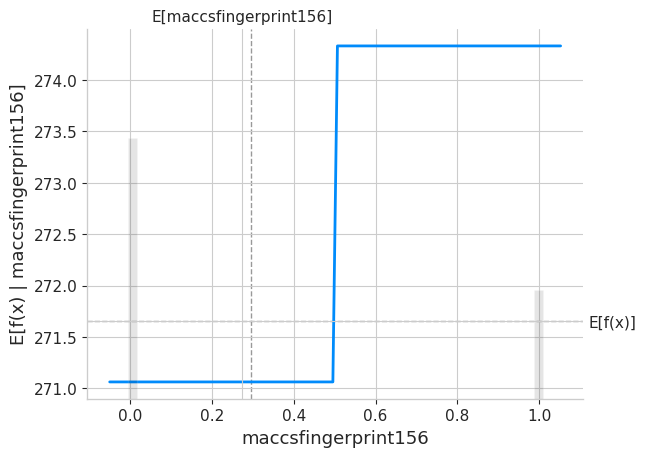

In [39]:
# explainer_xgb = shap.TreeExplainer(model)
# shap_values_xgb = explainer_xgb(X_all)
#
# # make a standard partial dependence plot with a single SHAP value overlaid
# shap.partial_dependence_plot(
#     "maccsfingerprint156",
#     model.predict,
#     X_all,
#     model_expected_value=True,
#     feature_expected_value=True,
#     show=True,
#     ice=False,
# )

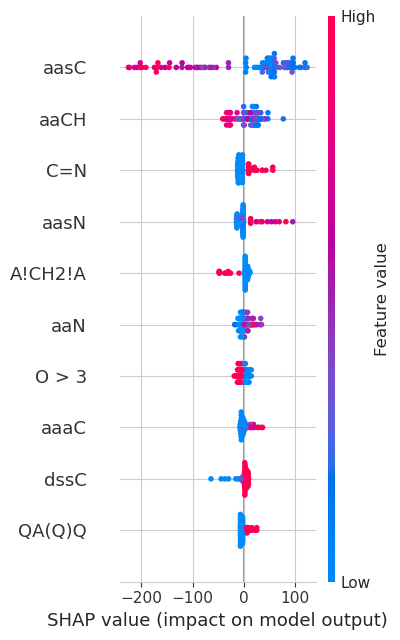

In [50]:
import matplotlib.pyplot as plt
#fig, ax = plt.subplots(1, 1, figsize=(4, 6.5))
shap.summary_plot(np.array(shap_values_all),
                      X_all,
                      max_display=10,
                      feature_names=list(column_mapping.values()),
                      plot_size=[4, 6.5],
                      show=False)

plt.savefig('plot_shap.png', bbox_inches='tight', dpi=300)
plt.show()

In [54]:
from PIL import Image
import requests
from io import BytesIO

def get_img(query, scale=0.5):
    base_url = 'https://smarts.plus/smartsview/download_rest?smarts='
    query = query.replace('%', '%25')
    query = query.replace('&', '%26')
    query = query.replace('+', '%2B')
    query = query.replace('#', '%23')
    query = query.replace(';', '%3B')

    url = base_url + query
    res = requests.get(url)
    image = Image.open(BytesIO(res.content))
    new_size = (int(image.width * scale), int(image.height * scale))
    image = image.resize(new_size)
    return image

In [63]:
most_important = ['aasC', 'aaCH', 'C=N', 'aasN', 'A!CH2!A', 'aaN', 'O > 3', 'aaaC', 'dssC', 'QA(Q)Q']
smarts_mi = {m: all_smarts[m] for m in most_important}

aasC


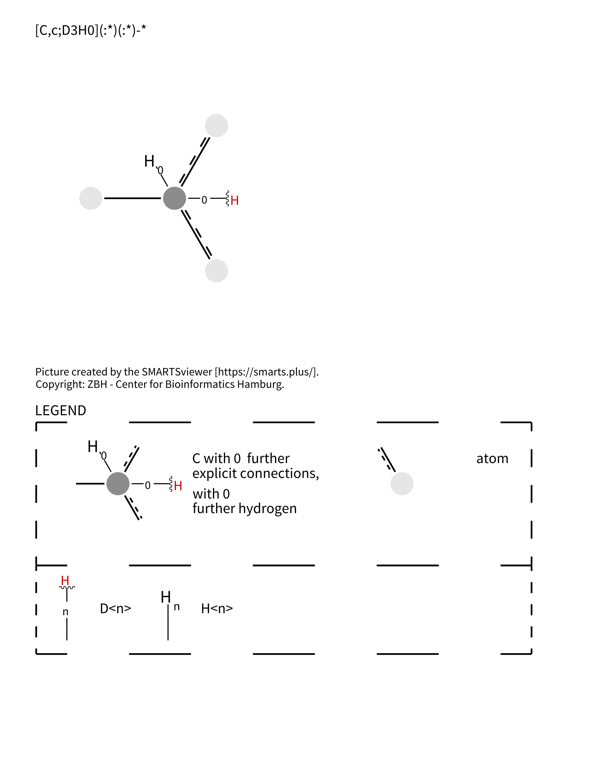

aaCH


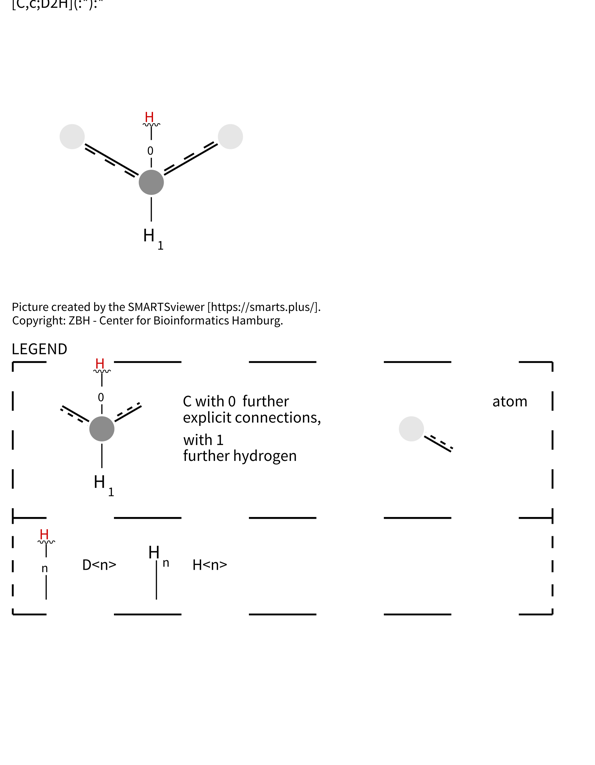

C=N


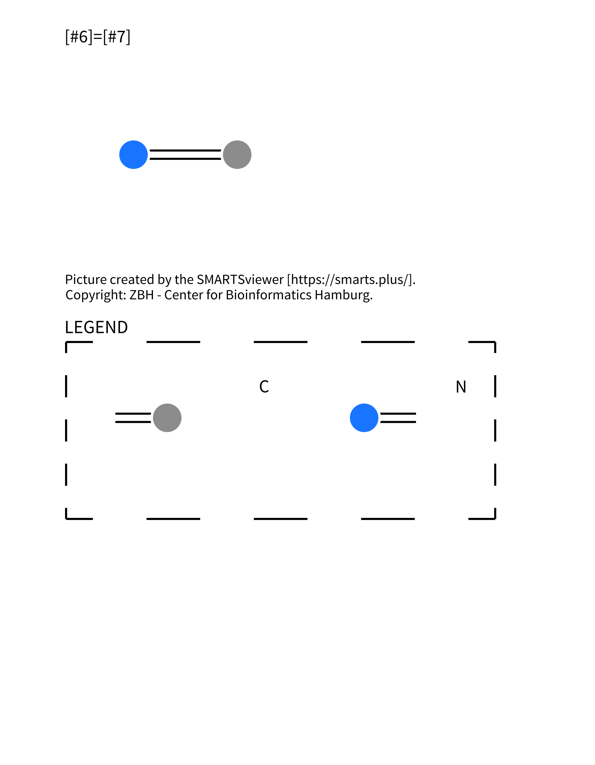

aasN


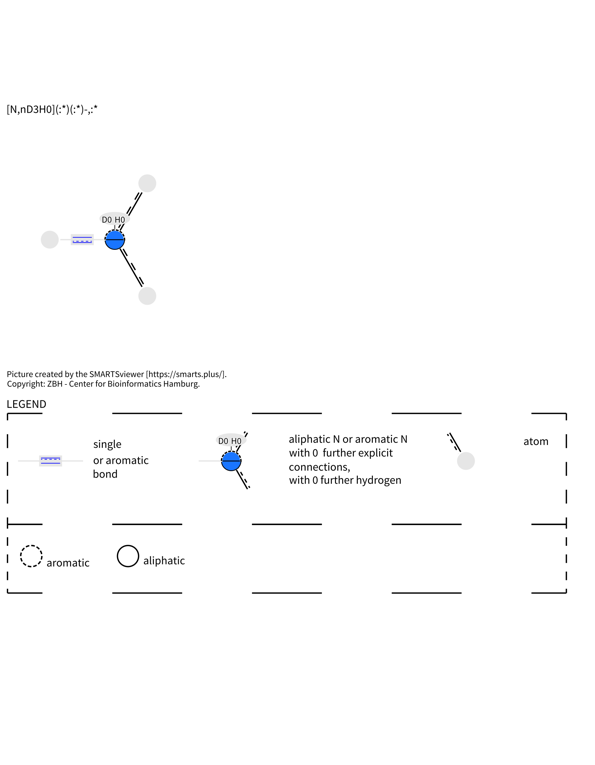

A!CH2!A


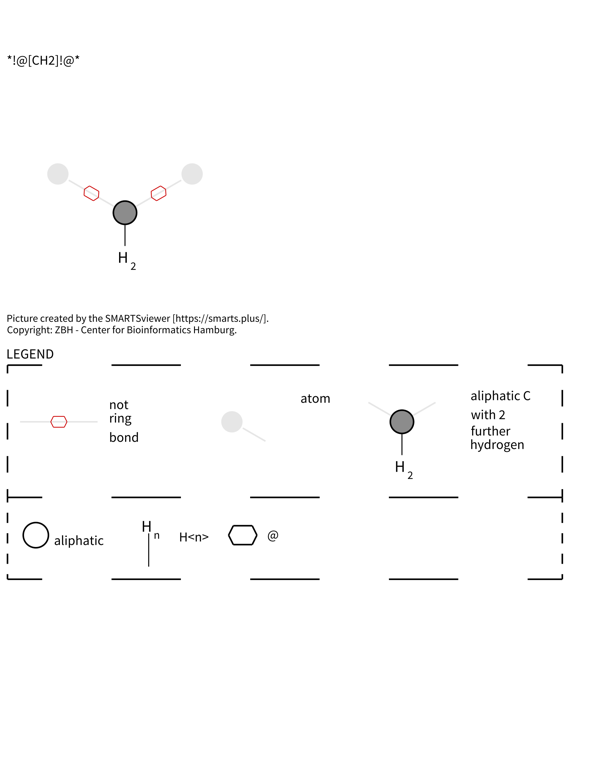

aaN


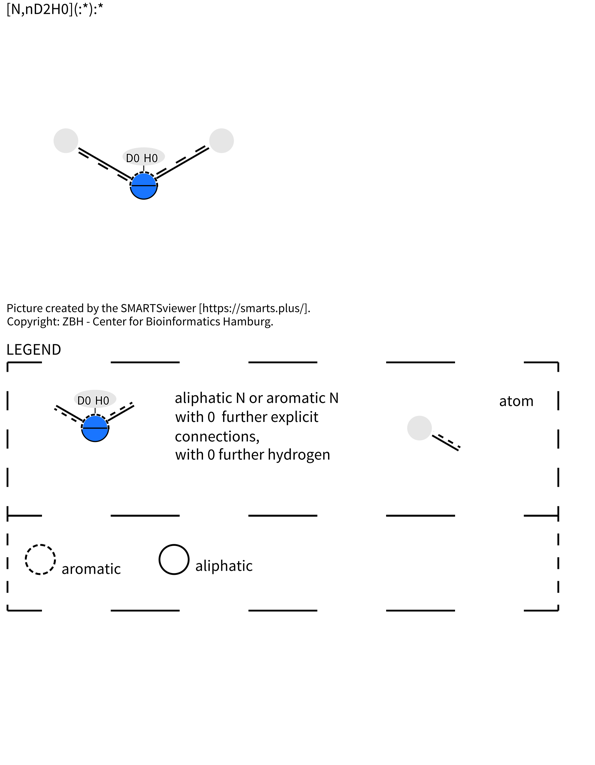

O > 3


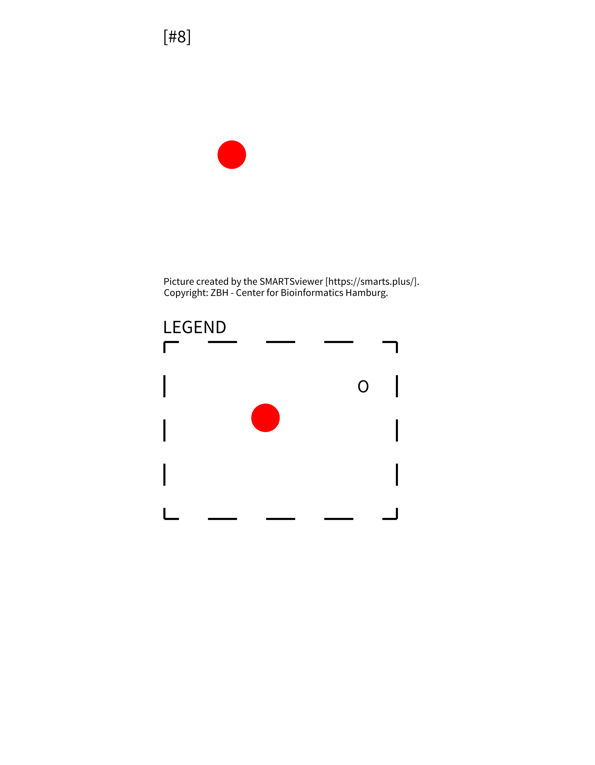

aaaC


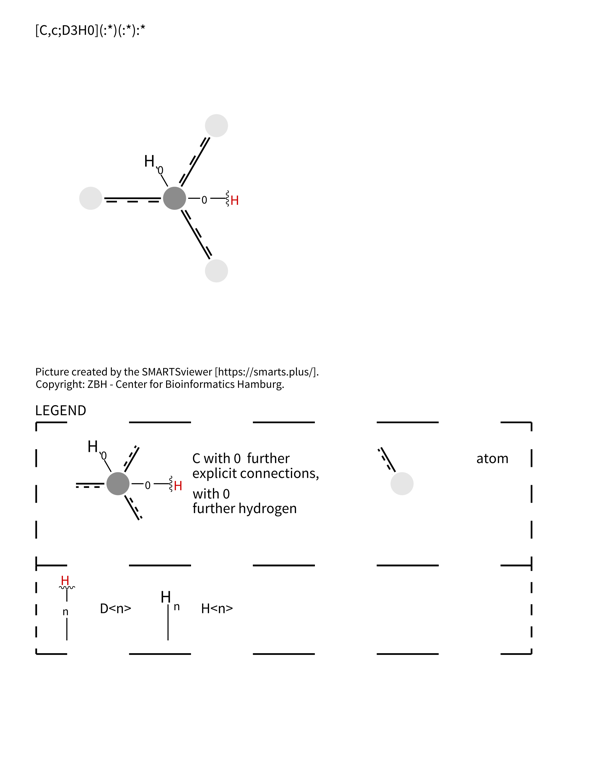

dssC


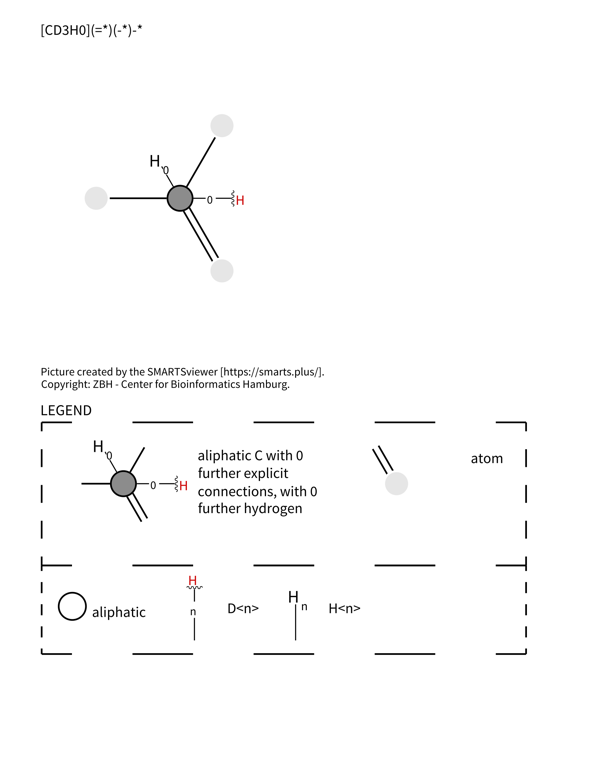

QA(Q)Q


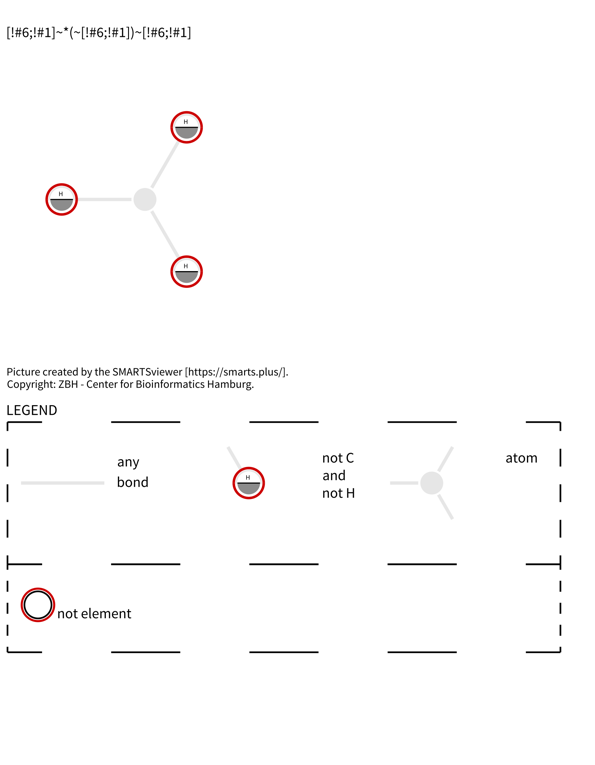

In [64]:
for feature, smart in smarts_mi.items():
    print(feature)
    im = get_img(smart, scale=0.3)
    display(im)

aasC


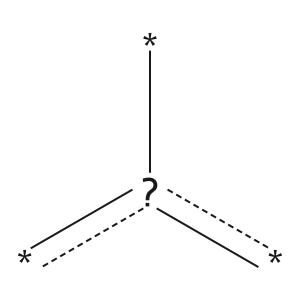

aaCH


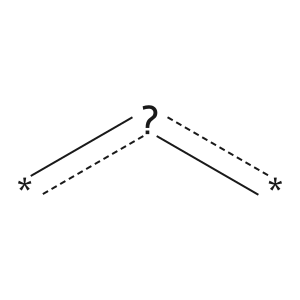

C=N


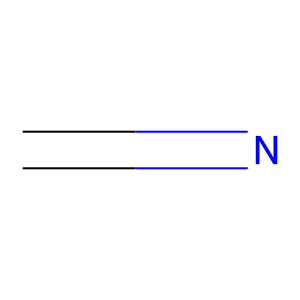

aasN


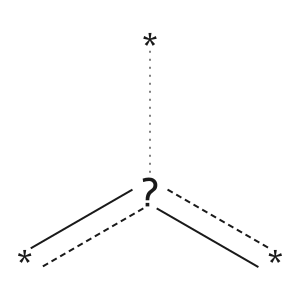

A!CH2!A


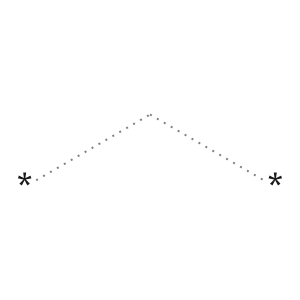

aaN


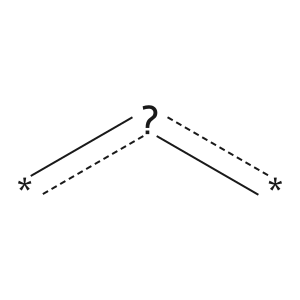

O > 3


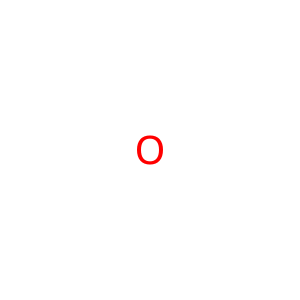

aaaC


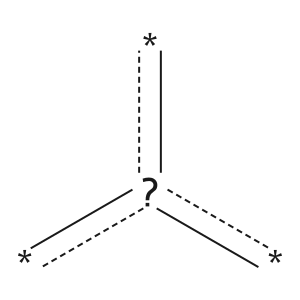

dssC


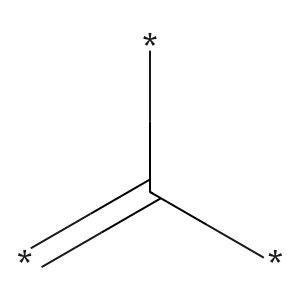

QA(Q)Q


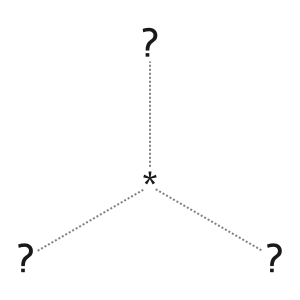

In [65]:
from matplotlib import pyplot as plt
from rdkit import Chem

for feature, smart in smarts_mi.items():
    smarts_mol = Chem.MolFromSmarts(smart)
    print(feature)
    display(Chem.Draw.MolToImage(smarts_mol))
    plt.show()

In [69]:
smarts_mi

{'aasC': '[C,c;D3H0](:*)(:*)-*',
 'aaCH': '[C,c;D2H](:*):*',
 'C=N': '[#6]=[#7]',
 'aasN': '[N,nD3H0](:*)(:*)-,:*',
 'A!CH2!A': '*!@[CH2]!@*',
 'aaN': '[N,nD2H0](:*):*',
 'O > 3': '[#8]',
 'aaaC': '[C,c;D3H0](:*)(:*):*',
 'dssC': '[CD3H0](=*)(-*)-*',
 'QA(Q)Q': '[!#6;!#1]~*(~[!#6;!#1])~[!#6;!#1]'}

In [67]:
from rdkit import rdBase
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw


def get_matches(smarts, df_all, column_mapping):

    good_molecules = {s: [] for s in smarts.keys()}
    for s in smarts.keys():
        key = column_mapping[s]
        non_zero_molecules = df_all[df_all[key] != 0]
        non_zero_molecules = non_zero_molecules['smiles'].tolist()
        good_molecules[s].extend(non_zero_molecules)

    for key in good_molecules.keys():
        print(key)
        mols = [Chem.MolFromSmiles(smi) for smi in sorted(good_molecules[key], key=lambda x: len(x))]
        match_smart = Chem.MolFromSmarts(smarts[key])
        highlight_lists = [mol.GetSubstructMatch(match_smart) for mol in mols]
        # print(highlight_lists[0])
        #display(Draw.MolsToImage([mols[0]], highlightAtomLists = [highlight_lists[0]], subImgSize=(500, 500)))
        for mol, h_list in zip(mols[:1], highlight_lists[:1]):
            display(Draw.MolsToGridImage([mol],
                                         highlightAtomLists=[h_list],
                                         molsPerRow=1,
                                         subImgSize=(500, 500)
                                         ))

aasC


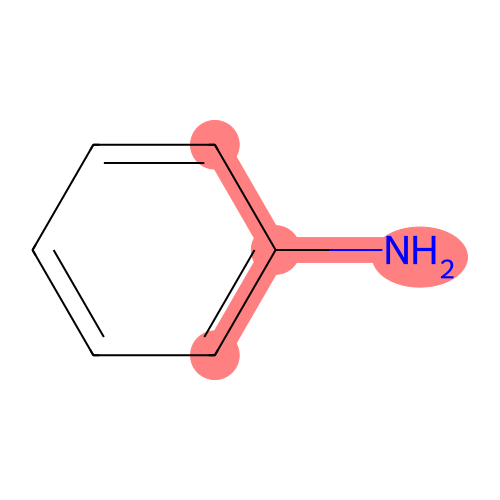

aaCH


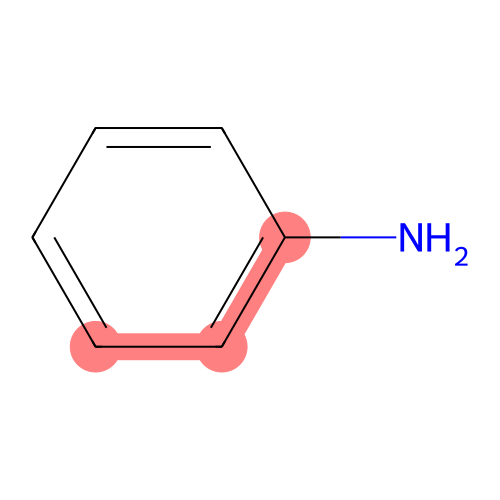

C=N


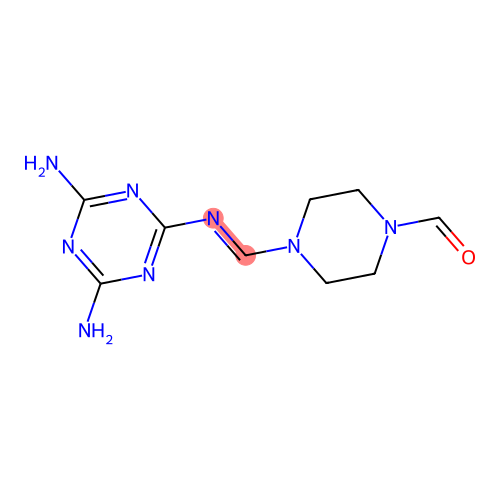

aasN


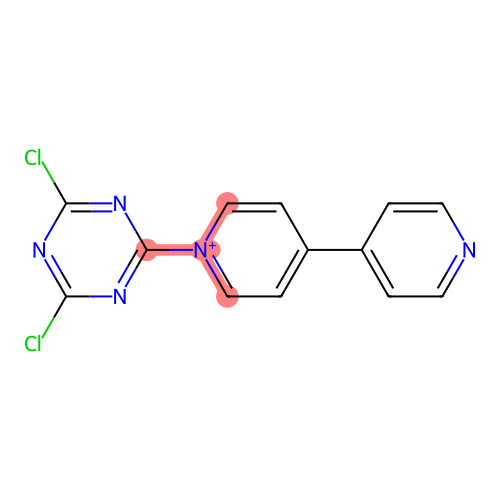

A!CH2!A


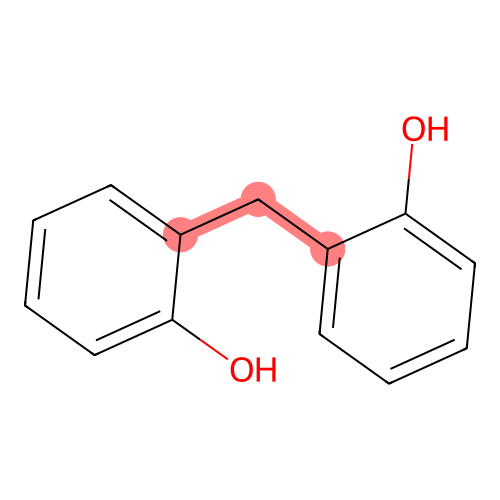

aaN


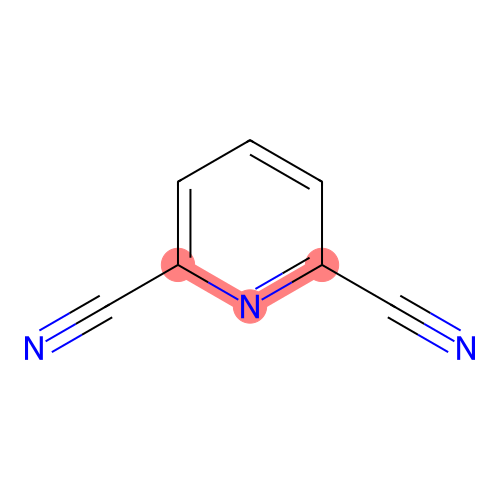

O > 3


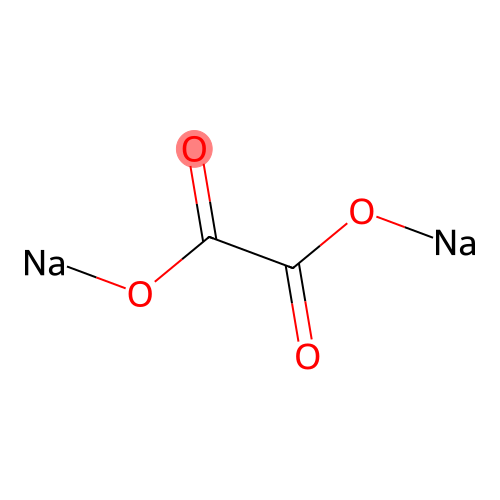

aaaC


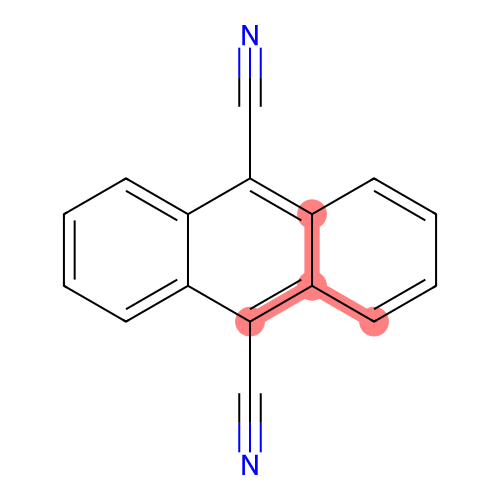

dssC


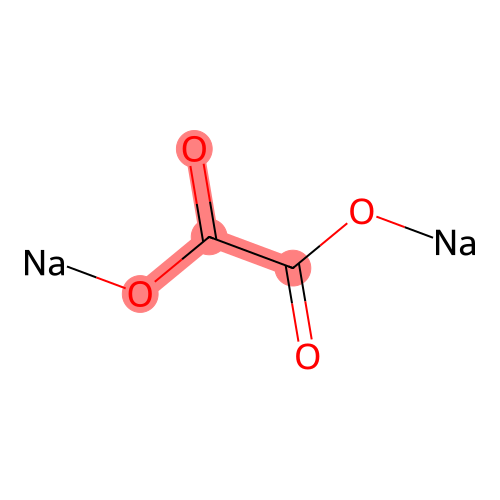

QA(Q)Q


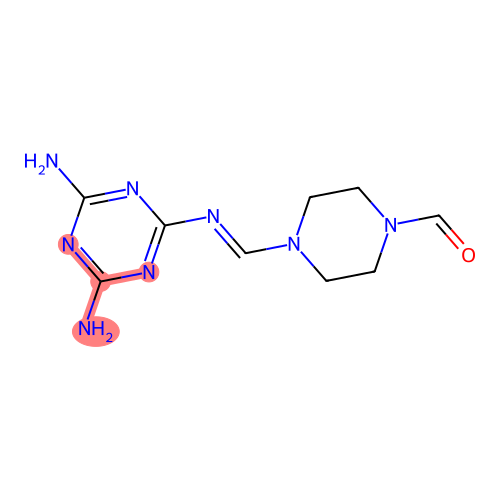

In [68]:
col_mapping = {v: k for k, v in column_mapping.items()}
get_matches(smarts_mi, df_all, col_mapping)

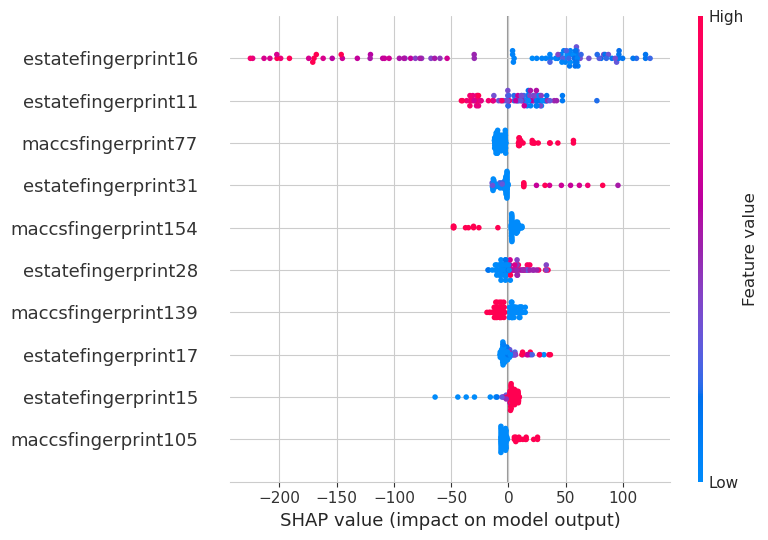

In [42]:
shap.summary_plot(np.array(shap_values_all),
                      X_all,
                      max_display=10,
                      feature_names=list(column_mapping.keys()),
                      show=True)

In [43]:
results_rf = cv_rf.train_pipeline(models[0])
f_importance_rf = cv_rf.shap_values

Training model Random Forest Regressor
Best score: -0.6635218519692409
 Best params: {'bootstrap': True, 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 10}
Best score: -0.5349216303189638
 Best params: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best score: -0.5356086357837516
 Best params: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 75}
Best score: -0.5808640505274626
 Best params: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}
Best score: -0.5277780778371925
 Best params: {'bootstrap': True, 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 15}
Best score: -0.5391161516589561
 Best params: {'bootstrap': True, 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 10}
Best score: -0.4307157117076391
 Best params: {'bootstrap':

In [44]:
print(results_rf)

{'pairwise_accuracy_score': 0.7908, 'baseline_mean_pairwise_accuracy_score': 0.5, 'baseline_median_pairwise_accuracy_score': 0.5, 'ndcg_score': 0.9471, 'baseline_mean_ndcg_score': 0.8354, 'baseline_median_ndcg_score': 0.8354, 'rmse': 160.198, 'baseline_mean_rmse': 194.7872, 'baseline_median_rmse': 194.6744, 'mape': 2265136473381767.5, 'baseline_mean_mape': 2.5441153907520268e+16, 'baseline_median_mape': 2.4664713959232416e+16, 'selected_features': 'all'}


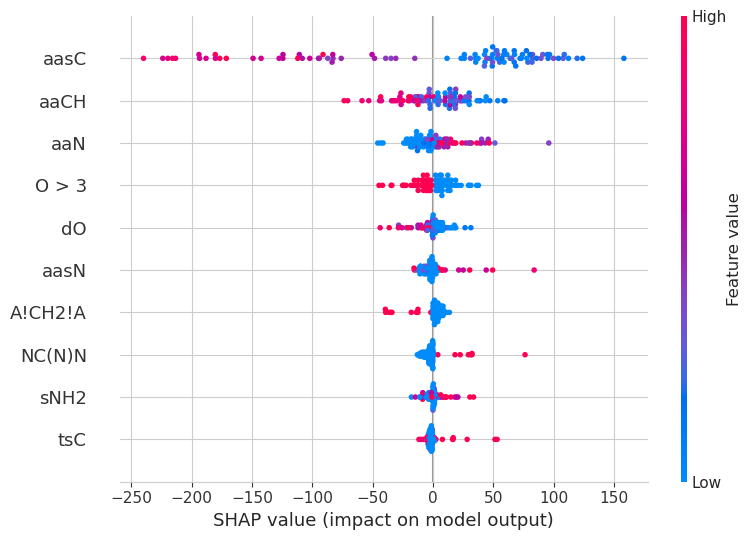

None

In [45]:
visualize_shap(f_importance_rf, X_all, column_mapping)

IndexError: list index out of range

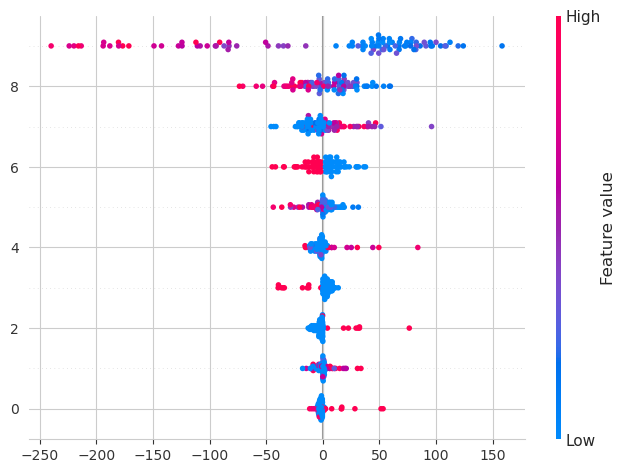

In [46]:
column_mapping2 = {feature_names[i]: f"maccsfingerprint{i}" for i in range(len(feature_names))}
visualize_shap(f_importance_rf, X_all, column_mapping2)

In [ ]:
ids = [88, 53, 121, 74, 104, 61, 147, 44, 135, 100, 102, 156, 122]
features = [column_mapping[f"maccsfingerprint{i}"] for i in ids]
feature_dict = {f"maccsfingerprint{ids[i]}": features[i] for i in range(len(ids))}
feature_dict

In [ ]:
smarts = {
    'OAAAO': "[#8]~*~*~*~[#8]",
    'QHAAQH': "[!#6;!#1;!H0]~*~*~[!#6;!#1;!H0]",
    'AN(A)A': "*~[#7](~*)~*",
    'A!N$A': "*!@[#7]@*",
    'A$A($A)$A': "*@*(@*)@*",
    'A$!A$A': "*@*!@*@*",
    'AQ(A)A': "*~[!#6;!#1](~*)~*",
    'C=CN': "[#6]=[#6]~[#7]",
    'O=A>1 ': "[#8]=*",
    'CL': "Cl",
    'C-O': "[#6]-[#8]",
    'OCO': "[#8]~[#6]~[#8]",
}

In [ ]:
from rdkit import Chem

for feature, smart in smarts.items():
    print(feature)
    smart_mol = Chem.MolFromSmarts(smart)
    display(Chem.Draw.MolToImage(smart_mol))
    display(get_img(smart, scale=0.3))

In [ ]:
print(column_mapping['maccsfingerprint103'])

In [ ]:
smarts.keys()

In [ ]:
good_molecules = {s: [] for s in smarts.keys()}
for key, value in feature_dict.items():
    non_zero_molecules = df_all[df_all[key] == 1]
    non_zero_molecules = non_zero_molecules['smiles'].tolist()
    if value != '8M Ring or larger':
        good_molecules[value].extend(non_zero_molecules)
good_molecules

In [ ]:
from rdkit import rdBase
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

for key in good_molecules.keys():
    print(key)
    mols = [Chem.MolFromSmiles(smi) for smi in sorted(good_molecules[key], key=lambda x: len(x))]
    match_smart = Chem.MolFromSmarts(smarts[key])
    #match_smart.Compute2DCoords()
    # for mol in mols:
    #     mol.Compute2DCoords()
    #     AllChem.GenerateDepictionMatching2DStructure(mol, match_smart, acceptFailure = True)
    highlight_lists = [mol.GetSubstructMatch(match_smart) for mol in mols]
    # print(highlight_lists[0])
    # display(Draw.MolsToImage([mols[0]], highlightAtomLists = [highlight_lists[0]], subImgSize=(500, 500)))
    for mol, h_list in zip(mols[:3], highlight_lists[:3]):
        display(Draw.MolsToGridImage([mol],
                             highlightAtomLists = [h_list],
                             molsPerRow=1,
                             subImgSize=(500, 500)
                            ))

In [ ]:
results_xgboost = cv_xgboost.train_pipeline(models[1])
f_importance_xgboost = cv_xgboost.shap_values

In [ ]:
print(results_xgboost)

In [ ]:
visualize_shap(f_importance_xgboost, X_all, column_mapping)

In [ ]:
from PIL import Image
import requests
from io import BytesIO

def get_img(query, scale=0.5):
    base_url = 'https://smarts.plus/smartsview/download_rest?smarts='
    query = query.replace('%', '%25')
    query = query.replace('&', '%26')
    query = query.replace('+', '%2B')
    query = query.replace('#', '%23')
    query = query.replace(';', '%3B')

    url = base_url + query
    res = requests.get(url)
    image = Image.open(BytesIO(res.content))
    new_size = (int(image.width * scale), int(image.height * scale))
    image = image.resize(new_size)
    return image

In [ ]:
estate_features = {f'estatefingerprint{i}': list(estate.keys())[i]  for i in range(len(list(estate.keys())))}
estate_features

In [ ]:
root_dir = '../../../data'
target = 'capacity_max'

metrics = ["pairwise_accuracy_score", "ndcg_score", "rmse", "smape"]
models = ["xgboost"]

data_dict = {
  'expert': 'data_experts1.csv',
  'zhu': 'data_zhu.csv',
  'saad': 'data_saad.csv',
  'expert2': 'data_experts2.csv',
  'expert3': 'data_experts3.csv',
}

fp_maccs = 'fingerprints_estate'

combo = ['expert', 'zhu', 'saad', 'expert2', 'expert3']

In [ ]:
import os
import pandas as pd

dataset_paths = {data_name: os.path.join(root_dir, fp_maccs, data_dict[data_name]) for data_name in combo}
dfs = {}
for data_name, data_path in dataset_paths.items():
    df = pd.read_csv(data_path)
    df.columns = df.columns.str.replace(r"[\[\]>]", "", regex=True)
    df = df.sort_values(by="smiles").reset_index(drop=True)
    dfs[data_name] = df

In [ ]:
from modules.predictor.data.utils import custom_data_kfold, combine_split
import pandas as pd

num_splits = 6
num_bins = 6
random_state = 42

# folds_experts1 = custom_data_kfold(df_expert1, df_expert1.loc[:, [target]], num_splits, num_bins, random_state)
# folds_all, df_all = combine_split(df_expert1, folds_experts1, df_expert2)
df_all = pd.concat([df for data_name, df in dfs.items()], ignore_index=True).sort_values(by="smiles").reset_index(drop=True)
df_all.fillna(0, inplace=True)
df_rest = None
print(df_all[df_all.isnull().any(axis=1)])

X_all = df_all.drop(columns=[target, "smiles"])
y_all = df_all.loc[:, [target]]
num_features = [f for f in X_all.columns]

folds_all = custom_data_kfold(df_all, df_all.loc[:, [target]], num_splits, num_bins, random_state)

In [ ]:
df_all.shape

In [ ]:
from modules.predictor.training_and_evaluation.train_eval import CrossValidationPipeline

cv_xgboost = CrossValidationPipeline(
    X_all,
    y_all,
    num_features,
    [],
    folds_all,
    metrics,
    "",
    "maccs_expert_expert2",
    oversampling=False,
    explainability=True,
    hyperparam_opt=(True, "grid_search"),
    verbose=True
)

In [ ]:
from modules.predictor.training_and_evaluation.explanations import explain_model
from modules.predictor.training_and_evaluation.model_factory import Models
import copy

_, model, param_grid = Models().get_model('xgboost')

# X, _ = self.preprocess_data(X, None)
model = cv_xgboost.tune_model(copy.deepcopy(X_all), copy.deepcopy(y_all), model, param_grid)

model.fit(X_all, y_all[y_all.columns[0]])
shap_values_all = explain_model(model, X_all)

In [ ]:
import shap

explainer_xgb = shap.TreeExplainer(model)
shap_values_xgb = explainer_xgb(X_all)

In [ ]:
import numpy as np

shap.summary_plot(np.array(shap_values_all),
                      X_all,
                      max_display=10,
                      feature_names=list(estate.keys()),
                      show=True)

In [ ]:
most_important = ['aasC', 'sNH2', 'aaN', 'aaCH', 'dsCH', 'dO', 'sBr', 'aaaC', 'sOH', 'tsC']
smarts_mi = {m: estate[m] for m in most_important}
smarts_mi


In [ ]:
col_mapping = {list(estate.keys())[i]: f'estatefingerprint{i}'  for i in range(len(list(estate.keys())))}
get_matches(smarts_mi, df_all, col_mapping)

In [ ]:
for feature, smart in smarts_mi.items():
    print(feature)
    im = get_img(smart, scale=0.3)
    display(im)

In [ ]:
from matplotlib import pyplot as plt
from rdkit import Chem

for feature, smart in smarts_mi.items():
    smarts_mol = Chem.MolFromSmarts(smart)
    print(feature)
    display(Chem.Draw.MolToImage(smarts_mol))
    plt.show()